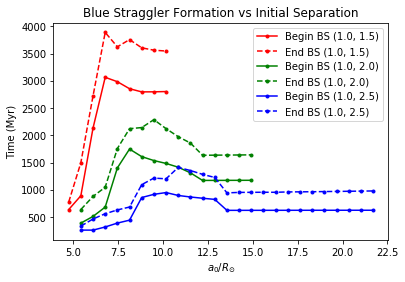

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
plt.rcParams['text.usetex'] = False 


"""
Blue Straggler Formation Analysis

This script uses BSE (Binary Star Evolution) to simulate binary systems
and determine when blue stragglers form and disappear.

Author: Emilie Desrochers Karlsson
"""


# -------------------------------
# PARAMETERS
# -------------------------------

BS_THRESHOLD = 1.01   # mass threshold for blue straggler


# -------------------------------
# FUNCTIONS
# -------------------------------

def run_bse(m1, m2, separation):
    """
    Runs BSE simulation for a binary system.

    Returns:
        time, mass1, mass2, kw1, kw2 arrays
    """
    with open("binary.in", "r") as f:
        lines = f.readlines()

    maxtime = 90000
    total_mass = m1 + m2
    period = np.sqrt((separation / 214.9)**3 * (1 / total_mass)) * 365

    lines[0] = "{} {} {} {} {} {} {} {}\n".format(
        m1, m2, maxtime, period, 1, 1, 0.02, 0.5
    )

    with open("binary.in", "w") as f:
        f.writelines(lines)

    os.system("./bse")

    data = np.loadtxt("binary.dat")
    data = np.stack(data, axis=-1)

    return data


def main_sequence_lifetime(m1):
    """
    Computes main sequence lifetime of a star using BSE.
    """
    data = run_bse(m1, 0, 0)

    time = data[0]
    mass = data[3]
    kw = data[1]

    ms_indices = [i for i in range(len(kw)) if kw[i] == 1]
    return time[ms_indices[-1]]


def compute_turnoff_mass():
    """
    Computes turnoff mass as a function of time.
    """
    masses = np.linspace(0.8, 10, 100)
    lifetimes = [main_sequence_lifetime(m) for m in masses]

    return interp1d(lifetimes, masses, kind="cubic", fill_value="extrapolate")


def blue_straggler_times(m1, m2, separation, turnoff_mass):
    """
    Returns the time interval where a blue straggler exists.
    """
    data = run_bse(m1, m2, separation)

    time = data[0]
    mass1 = data[3]
    mass2 = data[4]
    kw1 = data[1]
    kw2 = data[2]

    bs_times = []

    for i in range(len(time)):
        if kw1[i] == 1 and mass1[i] > BS_THRESHOLD * turnoff_mass(time[i]):
            bs_times.append(time[i])

        if kw2[i] == 1 and mass2[i] > BS_THRESHOLD * turnoff_mass(time[i]):
            bs_times.append(time[i])

    if not bs_times:
        return 0, 0

    return bs_times[0], bs_times[-1]


def run_simulation(m1, m2, separations, turnoff_mass):
    """
    Runs BS analysis over a range of initial semi major axes.
    """
    results = [blue_straggler_times(m1, m2, a, turnoff_mass) for a in separations]

    begins = [r[0] for r in results]
    ends = [r[1] for r in results]

    return begins, ends


def filter_valid(begins, ends, separations):
    """
    Removes invalid (zero) entries.
    """
    b, e, a = [], [], []

    for i in range(len(begins)):
        if begins[i] > 0:
            b.append(begins[i])
            e.append(ends[i])
            a.append(separations[i])

    return b, e, a


# -------------------------------
# MAIN SCRIPT
# -------------------------------

if __name__ == "__main__":

    turnoff_mass = compute_turnoff_mass()

    separations = np.linspace(0, 40, 60)

    configs = [
        (1.0, 1.5, 'red'),
        (1.0, 2.0, 'green'),
        (1.0, 2.5, 'blue')
    ]

    plt.figure()

    for m1, m2, color in configs:
        begins, ends = run_simulation(m1, m2, separations, turnoff_mass)
        b, e, a = filter_valid(begins, ends, separations)

        plt.plot(a, b, color=color, linestyle='-', marker='.',
                 label=f'Begin BS ({m1}, {m2})')

        plt.plot(a, e, color=color, linestyle='--', marker='.',
                 label=f'End BS ({m1}, {m2})')

    plt.xlabel(r'$a_0 / R_{\odot}$')
    plt.ylabel('Time (Myr)')
    plt.legend()
    plt.title('Blue Straggler Formation vs Initial Separation')

    plt.show()